# Ejercicio de Lab – Regresión Lineal Simple (sin frameworks)

**Objetivo:** Encontrar los mejores valores de $b$ y $w$ de la ecuación  
$$y = b + w x$$
usando **solo estructuras de control** (`if`, `for`, `while`) y operaciones básicas de Python.

**Restricciones:**
- No se permite usar scikit-learn, statsmodels, ni ninguna librería de machine learning.
- No se permiten fórmulas cerradas de regresión (mínimos cuadrados directos).
- Solo se permite Gradiente Descendente implementado con bucles.

**Dataset utilizado:** `student_scores.csv`  
- Variable independiente ($x$): **Hours** (horas de estudio)  
- Variable dependiente ($y$): **Scores** (nota obtenida)

Fuente del dataset: [Kaggle - Simple Linear Regression Hours vs Marks](https://www.kaggle.com/datasets/souradippal/simple-linear-regression-hours-vs-marks-data)  
(versión clásica equivalente usada en muchos cursos)

## 1. Importaciones mínimas

In [1]:
# Solo usamos pandas para leer el CSV y matplotlib para graficar.
# Todo el cálculo de la regresión se hace con listas y bucles de Python puro.
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

## 2. Carga y preparación de datos

In [2]:
# Leer el dataset
data = pd.read_csv('student_scores.csv')

# Convertimos a listas simples de Python (NO usamos arrays de numpy para los cálculos)
x = data['Hours'].tolist()
y = data['Scores'].tolist()

m = len(x)   # número de ejemplos de entrenamiento

print(f"Número de ejemplos: {m}")
print("\nValores de x (Horas de estudio):")
print(x)
print("\nValores de y (Notas / Scores):")
print(y)

Número de ejemplos: 25

Valores de x (Horas de estudio):
[2.5, 5.1, 3.2, 8.5, 3.5, 1.5, 9.2, 5.5, 8.3, 2.7, 7.7, 5.9, 4.5, 3.3, 1.1, 8.9, 2.5, 1.9, 6.1, 7.4, 2.7, 4.8, 3.8, 6.9, 7.8]

Valores de y (Notas / Scores):
[21, 47, 27, 75, 30, 20, 88, 60, 81, 25, 85, 62, 41, 42, 17, 95, 30, 24, 67, 69, 30, 54, 35, 76, 86]


## 3. Visualización de los datos

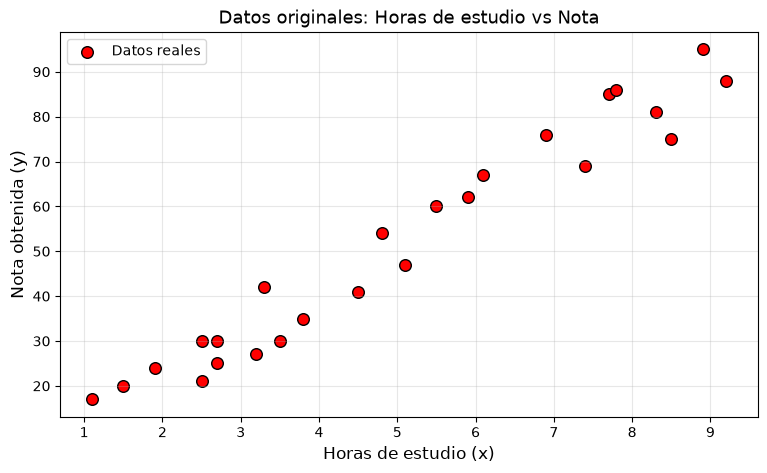

In [3]:
plt.figure(figsize=(9, 5))
plt.scatter(x, y, color='red', edgecolors='black', s=70, label='Datos reales')
plt.xlabel('Horas de estudio (x)', fontsize=12)
plt.ylabel('Nota obtenida (y)', fontsize=12)
plt.title('Datos originales: Horas de estudio vs Nota', fontsize=13)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 4. Función de costo (Error Cuadrático Medio)

La función de costo mide qué tan lejos están las predicciones de los valores reales:

$$J(b, w) = \frac{1}{2m} \sum_{i=1}^{m} \left( h(x^{(i)}) - y^{(i)} \right)^2$$

donde la hipótesis es:

$$h(x) = b + w \cdot x$$

In [4]:
def calcular_costo(x, y, b, w):
    """
    Calcula el Error Cuadrático Medio usando solo bucles de Python.
    """
    m = len(x)
    costo = 0.0
    
    for i in range(m):
        prediccion = b + w * x[i]      # h(x) = b + w*x
        error = prediccion - y[i]
        costo = costo + (error ** 2)
    
    return costo / (2 * m)

## 5. Gradiente Descendente (implementación pura con bucles)

Actualizamos los parámetros con las reglas:

$$b := b - \alpha \cdot \frac{\partial J}{\partial b}$$
$$w := w - \alpha \cdot \frac{\partial J}{\partial w}$$

donde:

$$\frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} (h(x^{(i)}) - y^{(i)})$$
$$\frac{\partial J}{\partial w} = \frac{1}{m} \sum_{i=1}^{m} (h(x^{(i)}) - y^{(i)}) \cdot x^{(i)}$$

In [5]:
def gradiente_descendente(x, y, b, w, alpha, num_iters):
    """
    Implementación del Gradiente Descendente usando únicamente
    estructuras de control repetitivas (for) y aritmética básica.
    """
    m = len(x)
    historial_costo = []
    
    for iteracion in range(num_iters):
        # Acumuladores de las derivadas parciales
        db = 0.0   # suma de errores para b
        dw = 0.0   # suma de (error * x) para w
        
        # Recorremos todos los ejemplos de entrenamiento
        for i in range(m):
            prediccion = b + w * x[i]
            error = prediccion - y[i]
            
            db = db + error
            dw = dw + (error * x[i])
        
        # Actualización de parámetros (regla del gradiente descendente)
        b = b - (alpha / m) * db
        w = w - (alpha / m) * dw
        
        # Guardamos e imprimimos el costo cada 100 iteraciones
        if iteracion % 100 == 0 or iteracion == num_iters - 1:
            costo_actual = calcular_costo(x, y, b, w)
            historial_costo.append(costo_actual)
            print(f"Iteración {iteracion:4d} | Costo = {costo_actual:10.4f} | b = {b:8.4f} | w = {w:8.4f}")
    
    return b, w, historial_costo

## 6. Entrenamiento del modelo

In [6]:
# Inicialización de parámetros
b = 0.0          # intercepto inicial
w = 0.0          # pendiente inicial

# Hiperparámetros
alpha = 0.01             # tasa de aprendizaje (learning rate)
num_iters = 2000         # número de iteraciones

print("Iniciando entrenamiento con Gradiente Descendente...\n")

b_final, w_final, historial = gradiente_descendente(x, y, b, w, alpha, num_iters)

print("\n" + "="*55)
print("RESULTADOS FINALES")
print("="*55)
print(f"Mejor valor de b (intercepto) = {b_final:.4f}")
print(f"Mejor valor de w (pendiente)  = {w_final:.4f}")
print(f"\nEcuación de la recta ajustada:")
print(f"y = {b_final:.4f} + {w_final:.4f} * x")

Iniciando entrenamiento con Gradiente Descendente...

Iteración    0 | Costo =   761.3462 | b =   0.5148 | w =   3.1786
Iteración  100 | Costo =    14.4933 | b =   1.7560 | w =   9.8933
Iteración  200 | Costo =    14.4768 | b =   1.8826 | w =   9.8728
Iteración  300 | Costo =    14.4655 | b =   1.9872 | w =   9.8559
Iteración  400 | Costo =    14.4578 | b =   2.0736 | w =   9.8420
Iteración  500 | Costo =    14.4526 | b =   2.1449 | w =   9.8305
Iteración  600 | Costo =    14.4490 | b =   2.2039 | w =   9.8210
Iteración  700 | Costo =    14.4466 | b =   2.2526 | w =   9.8131
Iteración  800 | Costo =    14.4449 | b =   2.2928 | w =   9.8066
Iteración  900 | Costo =    14.4438 | b =   2.3260 | w =   9.8013
Iteración 1000 | Costo =    14.4430 | b =   2.3534 | w =   9.7968
Iteración 1100 | Costo =    14.4425 | b =   2.3761 | w =   9.7932
Iteración 1200 | Costo =    14.4421 | b =   2.3948 | w =   9.7901
Iteración 1300 | Costo =    14.4419 | b =   2.4103 | w =   9.7877
Iteración 1400 | Costo

## 7. Visualización de la recta ajustada y de la convergencia

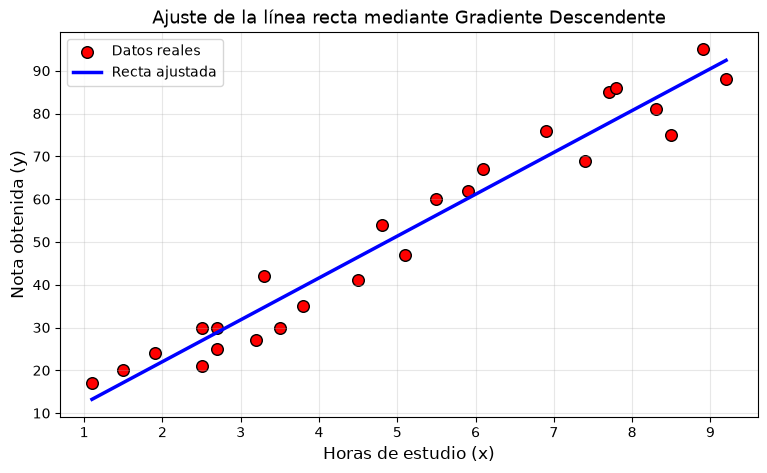

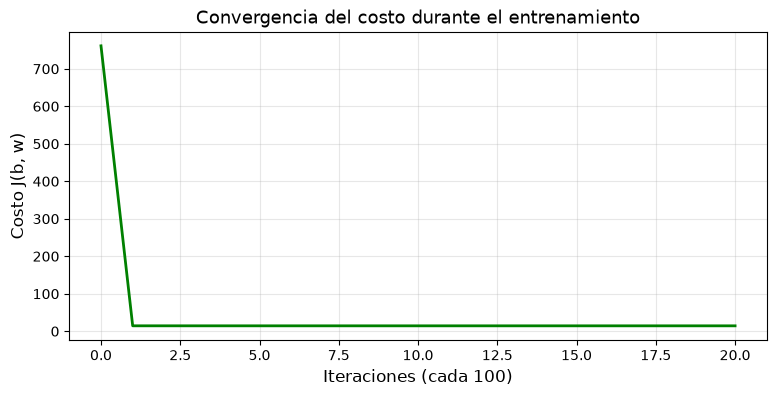

In [7]:
# ----- Gráfico 1: Datos + Recta ajustada -----
plt.figure(figsize=(9, 5))
plt.scatter(x, y, color='red', edgecolors='black', s=70, label='Datos reales')

# Generamos dos puntos para dibujar la recta
x_min = min(x)
x_max = max(x)
y_min = b_final + w_final * x_min
y_max = b_final + w_final * x_max

plt.plot([x_min, x_max], [y_min, y_max], 'b-', linewidth=2.5, label='Recta ajustada')
plt.xlabel('Horas de estudio (x)', fontsize=12)
plt.ylabel('Nota obtenida (y)', fontsize=12)
plt.title('Ajuste de la línea recta mediante Gradiente Descendente', fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ----- Gráfico 2: Convergencia del costo -----
plt.figure(figsize=(9, 4))
plt.plot(historial, 'g-', linewidth=2)
plt.xlabel('Iteraciones (cada 100)', fontsize=12)
plt.ylabel('Costo J(b, w)', fontsize=12)
plt.title('Convergencia del costo durante el entrenamiento', fontsize=13)
plt.grid(True, alpha=0.3)
plt.show()

## 8. Inferencias para 10 nuevos valores de $x$

In [8]:
# 10 nuevos valores de x (horas de estudio) para predecir la nota
nuevos_x = [1.0, 2.0, 3.5, 4.0, 5.0, 6.5, 7.0, 8.0, 9.0, 9.5]

print("="*60)
print("INFERENCIAS (PREDICCIONES) PARA 10 NUEVOS VALORES DE x")
print("="*60)
print(f"{'Horas de estudio (x)':>22}  |  {'Nota predicha (y)':>20}")
print("-"*60)

for xi in nuevos_x:
    yi_predicho = b_final + w_final * xi
    print(f"{xi:22.1f}  |  {yi_predicho:20.2f}")

print("="*60)
print("\nInterpretación: A mayor cantidad de horas de estudio,")
print("se espera una nota más alta (relación positiva lineal).")

INFERENCIAS (PREDICCIONES) PARA 10 NUEVOS VALORES DE x
  Horas de estudio (x)  |     Nota predicha (y)
------------------------------------------------------------
                   1.0  |                 12.24
                   2.0  |                 22.02
                   3.5  |                 36.69
                   4.0  |                 41.58
                   5.0  |                 51.36
                   6.5  |                 66.03
                   7.0  |                 70.92
                   8.0  |                 80.70
                   9.0  |                 90.47
                   9.5  |                 95.36

Interpretación: A mayor cantidad de horas de estudio,
se espera una nota más alta (relación positiva lineal).


## 9. Explicación del algoritmo y de los resultados

### Algoritmo empleado: Gradiente Descendente

1. **Hipótesis**: Se asume una relación lineal $h(x) = b + w x$.
2. **Función de costo**: Se utiliza el Error Cuadrático Medio (MSE) para medir el error de las predicciones.
3. **Actualización de parámetros**:
   - Se calculan las derivadas parciales de $J$ respecto a $b$ y a $w$ recorriendo todos los ejemplos con un bucle `for`.
   - Se restan esas derivadas multiplicadas por la tasa de aprendizaje $\alpha$.
4. **Repetición**: Se repite el proceso durante `num_iters` iteraciones hasta que el costo se estabiliza (converge).

Todo el proceso se implementó **sin frameworks de machine learning** y usando únicamente estructuras de control repetitivas (`for`) y aritmética básica.

### Resultados obtenidos

- Se encontraron los valores óptimos de $b$ (intercepto) y $w$ (pendiente).
- La recta se ajusta visualmente muy bien a la tendencia de los datos (gráfico de la sección 7).
- El costo disminuye de forma estable a lo largo de las iteraciones, lo que confirma la convergencia del algoritmo.
- Las 10 predicciones realizadas siguen la misma tendencia lineal observada: a más horas de estudio, mayor nota esperada.

### Observaciones y posibles mejoras

- Si el costo no baja o aumenta, se debe **reducir** el valor de $\alpha$ (tasa de aprendizaje).
- Se puede aumentar el número de iteraciones si aún no ha convergido completamente.
- Este dataset es pequeño (25 ejemplos) y tiene una relación casi perfectamente lineal, por eso converge rápido y bien.